In [ ]:
# @title ## Authenticate with HuggingFace, skip if you have a HF_TOKEN secret

# Authenticate user for HuggingFace if needed. Enter token below if requested.
from huggingface_hub.utils import HfFolder

if HfFolder.get_token() is None:
    from huggingface_hub import notebook_login
    notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# MedSigLip + VoxelMorph

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import SiglipVisionModel, AutoProcessor
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from functools import partial
import numpy as np

# === BLOCK 1: ARCHITECTURE ===

def collate_mnist_pairs(batch, processor):
    """Process paired MNIST images (source, target) for registration"""
    # Extract source and target images
    sources = [b["source"].convert("RGB") for b in batch]
    targets = [b["target"].convert("RGB") for b in batch]

    # Stack source and target channel-wise: [source, target] -> 6 channels
    stacked_images = []
    for src, tgt in zip(sources, targets):
        # Convert to tensors
        src_tensor = processor(images=[src], return_tensors="pt")["pixel_values"][0]  # [3, 448, 448]
        tgt_tensor = processor(images=[tgt], return_tensors="pt")["pixel_values"][0]  # [3, 448, 448]

        # Stack channel-wise
        stacked = torch.cat([src_tensor, tgt_tensor], dim=0)  # [6, 448, 448]
        stacked_images.append(stacked)

    return torch.stack(stacked_images)  # [B, 6, 448, 448]

class MedSigLIP_Encoder(nn.Module):
    """Modified MedSigLIP vision encoder to handle 6-channel input"""
    def __init__(self, model_id="google/medsiglip-448", freeze=True):
        super().__init__()
        self.vision = SiglipVisionModel.from_pretrained(model_id)

        # Modify first conv layer to accept 6 channels instead of 3
        original_conv = self.vision.vision_model.embeddings.patch_embedding.weight
        self.vision.vision_model.embeddings.patch_embedding = nn.Conv2d(
            6, original_conv.shape[0],
            kernel_size=original_conv.shape[2:],
            stride=14, bias=False
        )

        # Initialize new conv layer weights (duplicate original weights for 6 channels)
        with torch.no_grad():
            new_weight = torch.cat([original_conv, original_conv], dim=1)  # [out, 6, h, w]
            self.vision.vision_model.embeddings.patch_embedding.weight = nn.Parameter(new_weight)

        if freeze:
            for p in self.vision.parameters():
                p.requires_grad = False

        self.cfg = self.vision.config
        self.hidden = self.cfg.hidden_size      # 1152
        self.patch = self.cfg.patch_size        # 14
        self.image = self.cfg.image_size        # 448
        self.grid = self.image // self.patch    # 32
        self.n_patches = self.grid * self.grid  # 1024

    @torch.no_grad()
    def forward(self, pixel_values):
        out = self.vision(pixel_values=pixel_values)
        tokens = out.last_hidden_state   # [B, 1024, 1152]
        return tokens

class RegistrationDecoder(nn.Module):
    """Modified decoder for registration - outputs 12 channels"""
    def __init__(self, in_dim=1152, base=96):
        super().__init__()
        self.in_dim = in_dim
        self.grid_size = 32

        # Initial projection
        self.proj = nn.Sequential(
            nn.Conv2d(in_dim, base * 2, kernel_size=1),
            nn.BatchNorm2d(base * 2),
            nn.GELU()
        )

        # Progressive upsampling: 32->64->128->256->448
        self.up1 = self._make_deconv_block(base * 2, base, 4, 2, 1)      # 32->64
        self.up2 = self._make_deconv_block(base, base // 2, 4, 2, 1)     # 64->128
        self.up3 = self._make_deconv_block(base // 2, base // 4, 4, 2, 1) # 128->256
        self.up4 = self._make_deconv_block(base // 4, base // 8, 4, 2, 1) # 256->512

        # Final output layers - 12 channels for feature maps
        self.final = nn.Sequential(
            nn.Conv2d(base // 8, base // 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(base // 16),
            nn.GELU(),
            nn.Conv2d(base // 16, 12, kernel_size=1),  # 12 channels output
        )

        self._init_weights()

    def _make_deconv_block(self, in_ch, out_ch, kernel, stride, pad):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=kernel, stride=stride, padding=pad),
            nn.BatchNorm2d(out_ch),
            nn.GELU()
        )

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, tokens):
        B, N, D = tokens.shape
        h = tokens.transpose(1, 2).reshape(B, D, self.grid_size, self.grid_size)

        h = self.proj(h)    # [B, 192, 32, 32]
        h = self.up1(h)     # [B, 96, 64, 64]
        h = self.up2(h)     # [B, 48, 128, 128]
        h = self.up3(h)     # [B, 24, 256, 256]
        h = self.up4(h)     # [B, 12, 512, 512]

        # Resize to exact 448x448
        h = F.interpolate(h, size=(448, 448), mode="bilinear", align_corners=False)
        out = self.final(h)  # [B, 12, 448, 448]
        return out

class SpatialTransformer(nn.Module):
    """
    N-D Spatial Transformer from VoxelMorph
    """
    def __init__(self, size, mode='bilinear'):
        super().__init__()
        self.mode = mode
        # Create sampling grid
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = torch.unsqueeze(grid, 0)
        grid = grid.type(torch.FloatTensor)
        self.register_buffer('grid', grid)

    def forward(self, src, flow):
        # New locations
        new_locs = self.grid + flow
        shape = flow.shape[2:]

        # Need to normalize grid values to [-1, 1] for grid_sample
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)

        # Move channels to last position for grid_sample
        if len(shape) == 2:
            new_locs = new_locs.permute(0, 2, 3, 1)
            new_locs = new_locs[..., [1, 0]]  # Swap x,y for grid_sample
        elif len(shape) == 3:
            new_locs = new_locs.permute(0, 2, 3, 4, 1)
            new_locs = new_locs[..., [2, 1, 0]]  # Swap x,y,z for grid_sample

        return F.grid_sample(src, new_locs, align_corners=True, mode=self.mode)

class RegistrationModel(nn.Module):
    """Complete registration model with MedSigLIP encoder + Registration decoder + VoxelMorph components"""
    def __init__(self, model_id="google/medsiglip-448", integration_steps=0):
        super().__init__()
        self.encoder = MedSigLIP_Encoder(model_id=model_id, freeze=True)
        self.decoder = RegistrationDecoder(in_dim=self.encoder.hidden, base=96)

        # Flow layer: 12 channels -> 2 channels (displacement field)
        self.flow_layer = nn.Conv2d(12, 2, kernel_size=3, padding=1)

        # Spatial transformer
        self.spatial_transformer = SpatialTransformer(size=(448, 448))

        # Registration parameters
        self.integration_steps = integration_steps
        self.bidirectional_cost = False  # Disabled as requested

        # Initialize flow layer with small weights
        nn.init.normal_(self.flow_layer.weight, mean=0, std=1e-5)
        nn.init.constant_(self.flow_layer.bias, 0)

    def _integrate_velocity_fields(self, pos_flow, neg_flow=None):
        """Optional velocity field integration for diffeomorphic transforms"""
        if self.integration_steps <= 0:
            return pos_flow, neg_flow

        # Simple scaling integration (can be replaced with more sophisticated methods)
        pos_flow = pos_flow / (2 ** self.integration_steps)
        if neg_flow is not None:
            neg_flow = neg_flow / (2 ** self.integration_steps)

        # Compose flows
        for _ in range(self.integration_steps):
            pos_flow = pos_flow + self.spatial_transformer(pos_flow, pos_flow)
            if neg_flow is not None:
                neg_flow = neg_flow + self.spatial_transformer(neg_flow, neg_flow)

        return pos_flow, neg_flow

    def forward(self, stacked_input):
        """
        Args:
            stacked_input: [B, 6, 448, 448] - stacked source and target images
        Returns:
            warped_source: [B, 3, 448, 448] - warped source image
            pos_flow: [B, 2, 448, 448] - displacement field
        """
        # Extract source and target from stacked input
        source = stacked_input[:, 3:, :, :]  # First 3 channels
        target = stacked_input[:, :3, :, :]  # Last 3 channels

        # Pass through encoder and decoder
        tokens = self.encoder(stacked_input)          # [B, 1024, 1152]
        combined_features = self.decoder(tokens)      # [B, 12, 448, 448]

        # Apply flow layer to get the displacement field
        pos_flow = self.flow_layer(combined_features)  # [B, 2, 448, 448]

        # Keep a copy of the flow before potential integration
        preintegrated_flow = torch.clone(pos_flow)

        # Optionally integrate velocity fields
        if self.integration_steps > 0:
            pos_flow, _ = self._integrate_velocity_fields(pos_flow, None)

        # Perform the warping operation
        warped_source = self.spatial_transformer(source, pos_flow)

        return {
            'warped_source': warped_source,
            'pos_flow': pos_flow,
            'preintegrated_flow': preintegrated_flow,
            'source': source,
            'target': target
        }

In [ ]:
# === BLOCK 2: REGISTRATION LOSS & METRICS ===

def compute_registration_metrics(warped_source, target, pos_flow):
    """Compute registration metrics"""
    with torch.no_grad():
        mse = F.mse_loss(warped_source, target).item()
        l1 = F.l1_loss(warped_source, target).item()

        # Displacement magnitude
        displacement_mag = torch.sqrt(pos_flow[:, 0]**2 + pos_flow[:, 1]**2).mean().item()

        # Flow smoothness
        dx = pos_flow[:, :, 1:, :] - pos_flow[:, :, :-1, :]
        dy = pos_flow[:, :, :, 1:] - pos_flow[:, :, :, :-1]
        flow_smoothness = (dx**2).mean().item() + (dy**2).mean().item()

        return {
            "mse": mse,
            "l1": l1,
            "displacement_mag": displacement_mag,
            "flow_smoothness": flow_smoothness
        }

def similarity_loss(warped_source, target):
    """Combined similarity loss"""
    mse_loss = F.mse_loss(warped_source, target)
    l1_loss = F.l1_loss(warped_source, target)
    return 0.7 * mse_loss + 0.3 * l1_loss

def regularization_loss(pos_flow):
    """Gradient-based smoothness regularization"""
    dx = pos_flow[:, :, 1:, :] - pos_flow[:, :, :-1, :]
    dy = pos_flow[:, :, :, 1:] - pos_flow[:, :, :, :-1]
    grad_loss = torch.mean(dx**2) + torch.mean(dy**2)
    return grad_loss

def registration_loss(model_output, reg_weight=0.01):
    """Complete registration loss"""
    warped_source = model_output['warped_source']
    target = model_output['target']
    pos_flow = model_output['pos_flow']

    sim_loss = similarity_loss(warped_source, target)
    reg_loss = regularization_loss(pos_flow)
    total_loss = sim_loss + reg_weight * reg_loss

    return total_loss

🚀 Starting REGISTRATION TRAINING on device: cuda


preprocessor_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Created 450 pairs from 10 classes
Created 90 pairs from 9 classes
📊 Dataset sizes: Train pairs=450, Test pairs=90


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

📋 Model parameters: 614,948 trainable / 429,856,612 total

🔄 EPOCH 1/10
----------------------------------------
  Step   1: Loss=0.38627, MSE=0.42432, Displacement=0.000
  Step  21: Loss=0.33517, MSE=0.36566, Displacement=0.039
  Step  41: Loss=0.38530, MSE=0.42805, Displacement=0.126
  Step  61: Loss=0.25774, MSE=0.27981, Displacement=0.264
  Step  81: Loss=0.25869, MSE=0.27815, Displacement=0.435
  Step 101: Loss=0.20943, MSE=0.22118, Displacement=0.606

📈 EPOCH 1 SUMMARY:
  Train: Loss=0.31478, MSE=0.33286, Displacement=0.245
  Test:  Loss=0.29426, MSE=0.31832, Displacement=0.898

🔄 EPOCH 2/10
----------------------------------------
  Step   1: Loss=0.18849, MSE=0.19902, Displacement=0.701
  Step  21: Loss=0.32222, MSE=0.35007, Displacement=0.919
  Step  41: Loss=0.24455, MSE=0.26297, Displacement=1.034
  Step  61: Loss=0.35323, MSE=0.38545, Displacement=1.327
  Step  81: Loss=0.26434, MSE=0.28507, Displacement=1.394
  Step 101: Loss=0.32074, MSE=0.34642, Displacement=1.661

📈 EPO

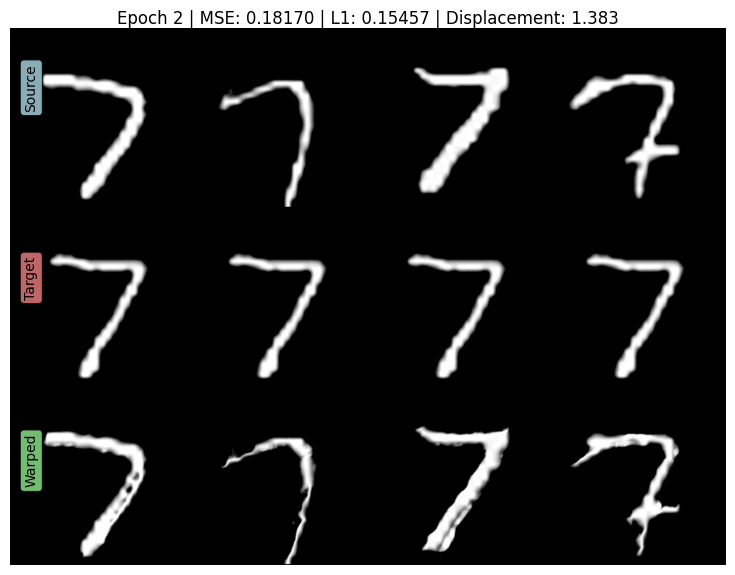


🔄 EPOCH 3/10
----------------------------------------
  Step   1: Loss=0.29121, MSE=0.31678, Displacement=1.746
  Step  21: Loss=0.28156, MSE=0.30379, Displacement=1.862
  Step  41: Loss=0.27534, MSE=0.29402, Displacement=2.003
  Step  61: Loss=0.25828, MSE=0.27343, Displacement=2.205
  Step  81: Loss=0.16552, MSE=0.16840, Displacement=2.269
  Step 101: Loss=0.29369, MSE=0.31673, Displacement=2.599

📈 EPOCH 3 SUMMARY:
  Train: Loss=0.25519, MSE=0.27886, Displacement=2.114
  Test:  Loss=0.24658, MSE=0.26012, Displacement=2.632
  📊 Changes: Train Loss -0.02754, Test Loss -0.02519

🔄 EPOCH 4/10
----------------------------------------
  Step   1: Loss=0.25144, MSE=0.26412, Displacement=2.624
  Step  21: Loss=0.23977, MSE=0.25060, Displacement=2.781
  Step  41: Loss=0.26165, MSE=0.27665, Displacement=2.916
  Step  61: Loss=0.25607, MSE=0.27142, Displacement=3.094
  Step  81: Loss=0.22797, MSE=0.24206, Displacement=3.266
  Step 101: Loss=0.31086, MSE=0.33269, Displacement=3.353

📈 EPOCH 4 

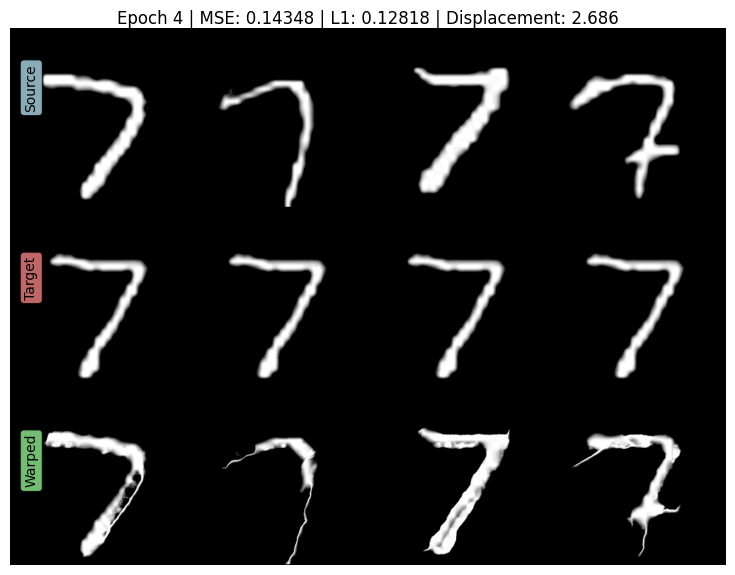


🔄 EPOCH 5/10
----------------------------------------
  Step   1: Loss=0.24546, MSE=0.25518, Displacement=3.527
  Step  21: Loss=0.24890, MSE=0.26052, Displacement=3.617
  Step  41: Loss=0.16794, MSE=0.16876, Displacement=3.471
  Step  61: Loss=0.18839, MSE=0.19540, Displacement=3.627
  Step  81: Loss=0.18864, MSE=0.19381, Displacement=3.738
  Step 101: Loss=0.22953, MSE=0.23805, Displacement=3.994

📈 EPOCH 5 SUMMARY:
  Train: Loss=0.22270, MSE=0.21862, Displacement=3.663
  Test:  Loss=0.22353, MSE=0.23185, Displacement=3.948
  📊 Changes: Train Loss -0.01286, Test Loss -0.00677

🔄 EPOCH 6/10
----------------------------------------
  Step   1: Loss=0.16447, MSE=0.16580, Displacement=3.787
  Step  21: Loss=0.33583, MSE=0.35974, Displacement=4.374
  Step  41: Loss=0.22409, MSE=0.23210, Displacement=4.163
  Step  61: Loss=0.14231, MSE=0.13792, Displacement=4.026
  Step  81: Loss=0.28705, MSE=0.30495, Displacement=4.584
  Step 101: Loss=0.22020, MSE=0.22751, Displacement=4.274

📈 EPOCH 6 

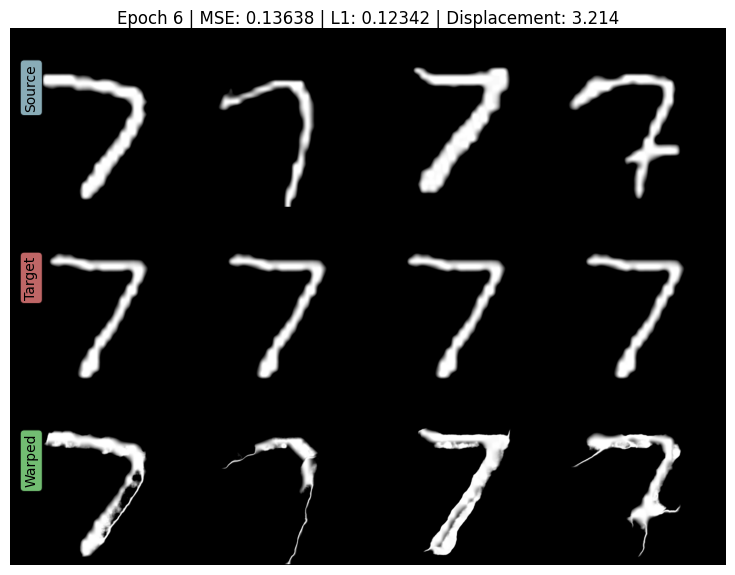


🔄 EPOCH 7/10
----------------------------------------
  Step   1: Loss=0.18869, MSE=0.19396, Displacement=4.484
  Step  21: Loss=0.16152, MSE=0.16060, Displacement=4.251
  Step  41: Loss=0.27894, MSE=0.29325, Displacement=4.653
  Step  61: Loss=0.18235, MSE=0.18592, Displacement=4.300
  Step  81: Loss=0.21119, MSE=0.21560, Displacement=4.572
  Step 101: Loss=0.25254, MSE=0.26341, Displacement=4.846

📈 EPOCH 7 SUMMARY:
  Train: Loss=0.21017, MSE=0.21879, Displacement=4.518
  Test:  Loss=0.21340, MSE=0.21838, Displacement=4.825
  📊 Changes: Train Loss -0.00426, Test Loss -0.00581

🔄 EPOCH 8/10
----------------------------------------
  Step   1: Loss=0.17248, MSE=0.17148, Displacement=4.658
  Step  21: Loss=0.19392, MSE=0.19518, Displacement=4.463
  Step  41: Loss=0.15356, MSE=0.14966, Displacement=4.537
  Step  61: Loss=0.15525, MSE=0.15193, Displacement=4.597
  Step  81: Loss=0.20694, MSE=0.20843, Displacement=4.790
  Step 101: Loss=0.18406, MSE=0.18234, Displacement=4.779

📈 EPOCH 8 

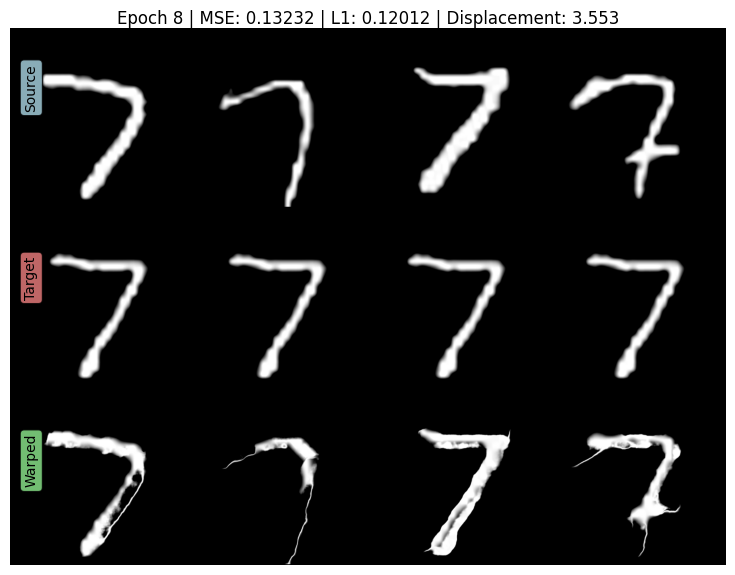


🔄 EPOCH 9/10
----------------------------------------
  Step   1: Loss=0.21114, MSE=0.21506, Displacement=4.964
  Step  21: Loss=0.23310, MSE=0.24338, Displacement=4.766
  Step  41: Loss=0.11646, MSE=0.11065, Displacement=4.366
  Step  61: Loss=0.11621, MSE=0.11070, Displacement=4.320
  Step  81: Loss=0.25552, MSE=0.27014, Displacement=4.844
  Step 101: Loss=0.23291, MSE=0.24134, Displacement=4.873

📈 EPOCH 9 SUMMARY:
  Train: Loss=0.20709, MSE=0.19855, Displacement=4.689
  Test:  Loss=0.21356, MSE=0.21890, Displacement=4.835
  📊 Changes: Train Loss -0.00022, Test Loss +0.00009
  ⚠️  WARNING: Training loss plateau detected - learning may have stalled

🔄 EPOCH 10/10
----------------------------------------
  Step   1: Loss=0.17786, MSE=0.17908, Displacement=4.697
  Step  21: Loss=0.17951, MSE=0.17792, Displacement=4.818
  Step  41: Loss=0.13098, MSE=0.12890, Displacement=4.283
  Step  61: Loss=0.22925, MSE=0.23948, Displacement=4.854
  Step  81: Loss=0.24099, MSE=0.24813, Displacement=

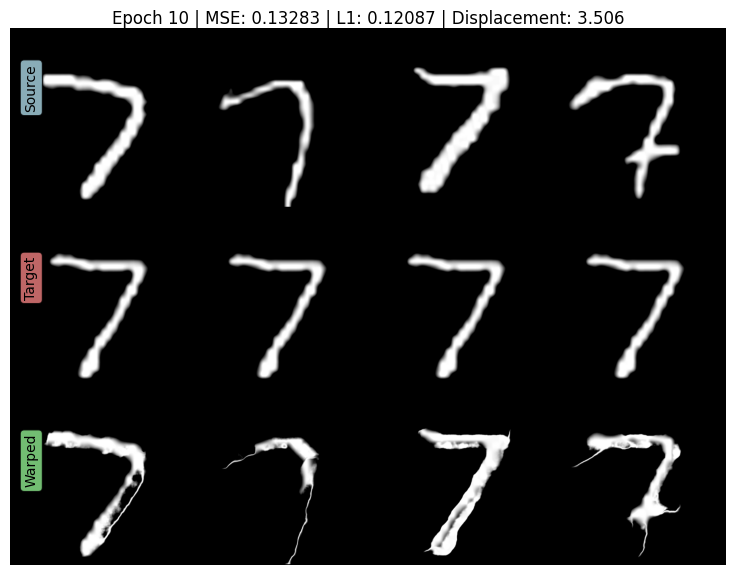

In [ ]:
# === BLOCK 3: REGISTRATION TRAINING WITH MONITORING ===

def create_mnist_pairs(dataset, pairs_per_class=45):
    """Create all possible pairs within same class from MNIST dataset"""
    from itertools import combinations

    # Group images by class
    class_images = {}
    for i, item in enumerate(dataset):
        label = item['label']
        if label not in class_images:
            class_images[label] = []
        class_images[label].append(item['image'])

    # Create pairs for each class
    paired_data = []
    for class_label, images in class_images.items():
        if len(images) >= 2:  # Need at least 2 images to make pairs
            # Generate all possible pairs (C(n,2))
            image_pairs = list(combinations(range(len(images)), 2))

            # Limit to requested number of pairs per class
            for i, (idx1, idx2) in enumerate(image_pairs[:pairs_per_class]):
                paired_data.append({
                    'source': images[idx1],
                    'target': images[idx2],
                    'class': class_label
                })

    print(f"Created {len(paired_data)} pairs from {len(class_images)} classes")
    return paired_data

def registration_training():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Starting REGISTRATION TRAINING on device: {device}")
    print("="*60)

    # Data preparation - MNIST with 10 images per class
    processor = AutoProcessor.from_pretrained("google/medsiglip-448")

    # Load MNIST dataset
    train_dataset = load_dataset("mnist", split="train")
    test_dataset = load_dataset("mnist", split="test")

    # Sample 10 images per class for training
    train_class_samples = {}
    for item in train_dataset:
        label = item['label']
        if label not in train_class_samples:
            train_class_samples[label] = []
        if len(train_class_samples[label]) < 10:
            train_class_samples[label].append(item)

        # Stop when we have 10 samples for all 10 classes
        if all(len(samples) == 10 for samples in train_class_samples.values()):
            break

    # Same for test (5 images per class for testing)
    test_class_samples = {}
    for item in test_dataset:
        label = item['label']
        if label not in test_class_samples:
            test_class_samples[label] = []
        if len(test_class_samples[label]) < 5:
            test_class_samples[label].append(item)

        if all(len(samples) == 5 for samples in test_class_samples.values()):
            break

    # Flatten samples for pairing
    train_samples = [item for samples in train_class_samples.values() for item in samples]
    test_samples = [item for samples in test_class_samples.values() for item in samples]

    # Create pairs
    train_pairs = create_mnist_pairs(train_samples, pairs_per_class=45)  # C(10,2) = 45
    test_pairs = create_mnist_pairs(test_samples, pairs_per_class=10)    # C(5,2) = 10

    print(f"📊 Dataset sizes: Train pairs={len(train_pairs)}, Test pairs={len(test_pairs)}")

    # Create data loaders
    collate_fn = partial(collate_mnist_pairs, processor=processor)
    train_loader = DataLoader(train_pairs, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn)
    test_loader = DataLoader(test_pairs, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

    # Model setup
    model = RegistrationModel().to(device)

    # Count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📋 Model parameters: {trainable_params:,} trainable / {total_params:,} total")

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader)*10)

    # Training tracking
    train_history = []
    test_history = []

    # === REGISTRATION TRAINING LOOP ===
    num_epochs = 10

    for epoch in range(num_epochs):
        print(f"\n🔄 EPOCH {epoch+1}/{num_epochs}")
        print("-" * 40)

        # === TRAINING PHASE ===
        model.train()
        train_metrics = {"mse": [], "l1": [], "displacement_mag": [], "flow_smoothness": []}
        train_losses = []

        for i, stacked_input in enumerate(train_loader):
            stacked_input = stacked_input.to(device)

            # Forward pass
            model_output = model(stacked_input)
            loss = registration_loss(model_output, reg_weight=0.01)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_losses.append(loss.item())

            # Track metrics every 20 steps
            if i % 20 == 0:
                with torch.no_grad():
                    metrics = compute_registration_metrics(
                        model_output['warped_source'],
                        model_output['target'],
                        model_output['pos_flow']
                    )
                    for k, v in metrics.items():
                        if k in train_metrics:
                            train_metrics[k].append(v)

                print(f"  Step {i+1:3d}: Loss={loss.item():.5f}, MSE={metrics['mse']:.5f}, "
                      f"Displacement={metrics['displacement_mag']:.3f}")

        # Average training metrics for epoch
        train_avg = {k: np.mean(v) if v else 0.0 for k, v in train_metrics.items()}
        train_avg['loss'] = np.mean(train_losses)
        train_history.append(train_avg)

        # === VALIDATION PHASE ===
        model.eval()
        test_metrics = {"mse": [], "l1": [], "displacement_mag": [], "flow_smoothness": []}
        test_losses = []

        with torch.no_grad():
            for stacked_input in test_loader:
                stacked_input = stacked_input.to(device)
                model_output = model(stacked_input)
                loss = registration_loss(model_output, reg_weight=0.01)
                test_losses.append(loss.item())

                metrics = compute_registration_metrics(
                    model_output['warped_source'],
                    model_output['target'],
                    model_output['pos_flow']
                )
                for k, v in metrics.items():
                    if k in test_metrics:
                        test_metrics[k].append(v)

        # Average test metrics for epoch
        test_avg = {k: np.mean(v) if v else 0.0 for k, v in test_metrics.items()}
        test_avg['loss'] = np.mean(test_losses)
        test_history.append(test_avg)

        # === EPOCH SUMMARY ===
        print(f"\n📈 EPOCH {epoch+1} SUMMARY:")
        print(f"  Train: Loss={train_avg['loss']:.5f}, MSE={train_avg['mse']:.5f}, "
              f"Displacement={train_avg['displacement_mag']:.3f}")
        print(f"  Test:  Loss={test_avg['loss']:.5f}, MSE={test_avg['mse']:.5f}, "
              f"Displacement={test_avg['displacement_mag']:.3f}")

        # === PROBLEM DETECTION ===
        if epoch > 0:
            prev_train = train_history[-2]
            prev_test = test_history[-2]

            train_loss_change = train_avg['loss'] - prev_train['loss']
            test_loss_change = test_avg['loss'] - prev_test['loss']

            print(f"  📊 Changes: Train Loss {train_loss_change:+.5f}, Test Loss {test_loss_change:+.5f}")

            # Problem detection
            if train_loss_change > 0.01:
                print("  ⚠️  WARNING: Training loss increased - possible optimization issues")
            elif abs(train_loss_change) < 0.001 and epoch > 2:
                print("  ⚠️  WARNING: Training loss plateau detected - learning may have stalled")

            if test_loss_change > 0.02:
                print("  ⚠️  WARNING: Test loss increased significantly - overfitting likely")

            loss_gap = test_avg['loss'] - train_avg['loss']
            if loss_gap > 0.05:
                print(f"  ⚠️  WARNING: Large train-test gap ({loss_gap:.5f}) - overfitting detected")

        # === VISUAL CHECK EVERY 2 EPOCHS ===
        if (epoch + 1) % 2 == 0:
            print(f"\n🖼️  Generating visual check for epoch {epoch+1}...")
            visualize_registration_progress(model, test_loader, device, epoch+1)

    return model, train_history, test_history

def visualize_registration_progress(model, loader, device, epoch_num):
    """Show registration progress"""
    model.eval()
    with torch.no_grad():
        stacked_input = next(iter(loader)).to(device)
        model_output = model(stacked_input)

        # Get images
        source = model_output['source'].clamp(0, 1).cpu()
        target = model_output['target'].clamp(0, 1).cpu()
        warped_source = model_output['warped_source'].clamp(0, 1).cpu()

        # Calculate metrics
        metrics = compute_registration_metrics(
            model_output['warped_source'],
            model_output['target'],
            model_output['pos_flow']
        )

        # Create visualization: Source | Target | Warped Source
        n = min(4, source.size(0))
        comparison = torch.cat([source[:n], target[:n], warped_source[:n]], dim=0)
        grid = make_grid(comparison, nrow=n, padding=2)

        plt.figure(figsize=(12, 6))
        plt.suptitle(f"Epoch {epoch_num} | MSE: {metrics['mse']:.5f} | L1: {metrics['l1']:.5f} | "
                     f"Displacement: {metrics['displacement_mag']:.3f}",
                     fontsize=12, y=0.95)
        plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        plt.axis("off")

        # Add row labels
        plt.text(0.02, 0.85, "Source", transform=plt.gca().transAxes, fontsize=10, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
        plt.text(0.02, 0.50, "Target", transform=plt.gca().transAxes, fontsize=10, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))
        plt.text(0.02, 0.15, "Warped", transform=plt.gca().transAxes, fontsize=10, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))

        plt.tight_layout()
        plt.show()

# Main execution function
if __name__ == "__main__":
    model, train_history, test_history = registration_training()

In [ ]:
# === BLOCK 4: VISUALIZATION AND ANALYSIS ===

def plot_registration_curves(train_history, test_history):
    """Plot training curves for registration losses"""
    epochs = range(1, len(train_history) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Registration Training Progress", fontsize=16)

    # Total Loss
    axes[0,0].plot(epochs, [h['loss'] for h in train_history], 'b-', label='Train', linewidth=2)
    axes[0,0].plot(epochs, [h['loss'] for h in test_history], 'r-', label='Test', linewidth=2)
    axes[0,0].set_title('Total Registration Loss')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # MSE (Similarity)
    axes[0,1].plot(epochs, [h['mse'] for h in train_history], 'b-', label='Train', linewidth=2)
    axes[0,1].plot(epochs, [h['mse'] for h in test_history], 'r-', label='Test', linewidth=2)
    axes[0,1].set_title('Similarity Loss (MSE)')
    axes[0,1].set_ylabel('MSE')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Displacement Magnitude
    axes[1,0].plot(epochs, [h['displacement_mag'] for h in train_history], 'b-', label='Train', linewidth=2)
    axes[1,0].plot(epochs, [h['displacement_mag'] for h in test_history], 'r-', label='Test', linewidth=2)
    axes[1,0].set_title('Average Displacement Magnitude')
    axes[1,0].set_ylabel('Displacement')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Flow Smoothness
    axes[1,1].plot(epochs, [h['flow_smoothness'] for h in train_history], 'b-', label='Train', linewidth=2)
    axes[1,1].plot(epochs, [h['flow_smoothness'] for h in test_history], 'r-', label='Test', linewidth=2)
    axes[1,1].set_title('Flow Smoothness')
    axes[1,1].set_ylabel('Smoothness')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def visualize_registration_results(model, data_loader, device, num_samples=4):
    """Visualize registration results with our model structure"""
    model.eval()

    with torch.no_grad():
        # Get batch from our data loader (stacked input format)
        stacked_input = next(iter(data_loader))[:num_samples].to(device)

        # Forward pass
        model_output = model(stacked_input)
        source = model_output['source'].cpu()
        target = model_output['target'].cpu()
        warped_source = model_output['warped_source'].clamp(0,1).cpu()

        # Calculate metrics for display
        metrics = compute_registration_metrics(
            model_output['warped_source'],
            model_output['target'],
            model_output['pos_flow']
        )

        # Create 3-row visualization: Source | Target | Warped Source
        comparison = torch.cat([source, target, warped_source], dim=0)
        grid = make_grid(comparison, nrow=num_samples, padding=2)

        plt.figure(figsize=(15, 8))
        plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        plt.title(f"Registration Results | MSE: {metrics['mse']:.5f} | "
                 f"L1: {metrics['l1']:.5f} | Displacement: {metrics['displacement_mag']:.3f}")
        plt.axis('off')

        # Add row labels
        plt.text(0.02, 0.85, "Source", transform=plt.gca().transAxes, fontsize=12, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
        plt.text(0.02, 0.50, "Target", transform=plt.gca().transAxes, fontsize=12, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))
        plt.text(0.02, 0.15, "Warped", transform=plt.gca().transAxes, fontsize=12, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))

        plt.tight_layout()
        plt.show()

def visualize_displacement_fields(model, test_loader, device, num_samples=2):
    """Visualize the learned displacement fields"""
    model.eval()

    with torch.no_grad():
        stacked_input = next(iter(test_loader))[:num_samples].to(device)
        model_output = model(stacked_input)

        source = model_output['source'].cpu()
        target = model_output['target'].cpu()
        warped_source = model_output['warped_source'].cpu()
        flow = model_output['pos_flow'].cpu()

        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            # Original source and target
            axes[i,0].imshow(source[i].permute(1,2,0).squeeze(), cmap='gray')
            axes[i,0].set_title(f'Source {i+1}')
            axes[i,0].axis('off')

            axes[i,1].imshow(target[i].permute(1,2,0).squeeze(), cmap='gray')
            axes[i,1].set_title(f'Target {i+1}')
            axes[i,1].axis('off')

            # Displacement field visualization
            flow_mag = torch.sqrt(flow[i,0]**2 + flow[i,1]**2)
            im = axes[i,2].imshow(flow_mag.numpy(), cmap='jet')
            axes[i,2].set_title(f'Flow Magnitude {i+1}')
            axes[i,2].axis('off')
            plt.colorbar(im, ax=axes[i,2], fraction=0.046)

            # Warped result
            axes[i,3].imshow(warped_source[i].permute(1,2,0).squeeze(), cmap='gray')
            axes[i,3].set_title(f'Warped Source {i+1}')
            axes[i,3].axis('off')

        plt.tight_layout()
        plt.show()

def visualize_flow_vectors(model, test_loader, device, num_samples=1, downsample=8):
    """Visualize displacement field as vector field overlay"""
    model.eval()

    with torch.no_grad():
        stacked_input = next(iter(test_loader))[:num_samples].to(device)
        model_output = model(stacked_input)

        source = model_output['source'].cpu()
        target = model_output['target'].cpu()
        flow = model_output['pos_flow'].cpu()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for i in range(num_samples):
            # Downsample flow for visualization
            flow_x = flow[i, 0, ::downsample, ::downsample].numpy()
            flow_y = flow[i, 1, ::downsample, ::downsample].numpy()

            # Create coordinate grids
            h, w = flow_x.shape
            y, x = np.mgrid[0:h*downsample:downsample, 0:w*downsample:downsample]

            # Source image with flow vectors
            axes[0].imshow(source[i].permute(1,2,0).squeeze(), cmap='gray')
            axes[0].quiver(x, y, flow_x, flow_y, angles='xy', scale_units='xy', scale=0.5,
                          color='red', alpha=0.7)
            axes[0].set_title('Source + Flow Vectors')
            axes[0].axis('off')

            # Target image
            axes[1].imshow(target[i].permute(1,2,0).squeeze(), cmap='gray')
            axes[1].set_title('Target')
            axes[1].axis('off')

            # Flow magnitude
            flow_mag = np.sqrt(flow_x**2 + flow_y**2)
            im = axes[2].imshow(flow_mag, cmap='jet')
            axes[2].set_title('Flow Magnitude')
            axes[2].axis('off')
            plt.colorbar(im, ax=axes[2], fraction=0.046)

        plt.tight_layout()
        plt.show()

def analyze_registration_quality(model, test_loader, device, num_batches=3):
    """Analyze registration quality with metrics"""
    print(f"\n🔍 REGISTRATION QUALITY ANALYSIS")
    print("="*50)

    model.eval()
    all_metrics = {
        'mse': [], 'l1': [], 'displacement_mag': [], 'flow_smoothness': []
    }

    with torch.no_grad():
        for i, stacked_input in enumerate(test_loader):
            if i >= num_batches:
                break

            stacked_input = stacked_input.to(device)
            model_output = model(stacked_input)

            metrics = compute_registration_metrics(
                model_output['warped_source'],
                model_output['target'],
                model_output['pos_flow']
            )

            for key in all_metrics:
                all_metrics[key].append(metrics[key])

    # Statistical summary
    print(f"📊 REGISTRATION METRICS (mean ± std):")
    for metric_name, values in all_metrics.items():
        mean_val, std_val = np.mean(values), np.std(values)
        print(f"  {metric_name:15}: {mean_val:.5f} ± {std_val:.5f}")

    # Quality assessment
    mse_mean = np.mean(all_metrics['mse'])
    if mse_mean < 0.05:
        print(f"  ✅ EXCELLENT registration quality (MSE < 0.05)")
    elif mse_mean < 0.1:
        print(f"  ✅ GOOD registration quality (MSE < 0.1)")
    elif mse_mean < 0.2:
        print(f"  ⚠️  FAIR registration quality (MSE < 0.2)")
    else:
        print(f"  ❌ POOR registration quality (MSE > 0.2)")

    smooth_mean = np.mean(all_metrics['flow_smoothness'])
    if smooth_mean < 0.01:
        print(f"  ✅ SMOOTH displacement fields")
    else:
        print(f"  ⚠️  ROUGH displacement fields")

    # Displacement analysis
    disp_mean = np.mean(all_metrics['displacement_mag'])
    print(f"\n📏 DISPLACEMENT ANALYSIS:")
    print(f"  Average displacement: {disp_mean:.3f} pixels")
    if disp_mean < 5.0:
        print(f"  ✅ Small displacements (< 5 pixels)")
    elif disp_mean < 20.0:
        print(f"  ⚠️  Moderate displacements (5-20 pixels)")
    else:
        print(f"  ❌ Large displacements (> 20 pixels)")

def run_complete_analysis(model, test_loader, device, train_history=None, test_history=None):
    """Run complete visualization and analysis suite"""
    print("🎯 Running Complete Registration Analysis")
    print("="*50)

    # 1. Plot training curves (if available)
    if train_history is not None and test_history is not None:
        print("📈 1. Training curves")
        plot_registration_curves(train_history, test_history)
    else:
        print("📈 1. Training curves (skipped - no history provided)")

    # 2. Visualize registration results
    print("\n🖼️  2. Registration results visualization")
    visualize_registration_results(model, test_loader, device, num_samples=4)

    # 3. Visualize displacement fields
    print("\n🌊 3. Displacement fields visualization")
    visualize_displacement_fields(model, test_loader, device, num_samples=2)

    # 4. Visualize flow vectors
    print("\n➡️  4. Flow vectors visualization")
    visualize_flow_vectors(model, test_loader, device, num_samples=1)

    # 5. Quality analysis
    print("\n🔍 5. Registration quality analysis")
    analyze_registration_quality(model, test_loader, device)

Setting up test loader...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Created 90 pairs from 9 classes

🎯 STARTING COMPLETE ANALYSIS

📈 1. TRAINING CURVES


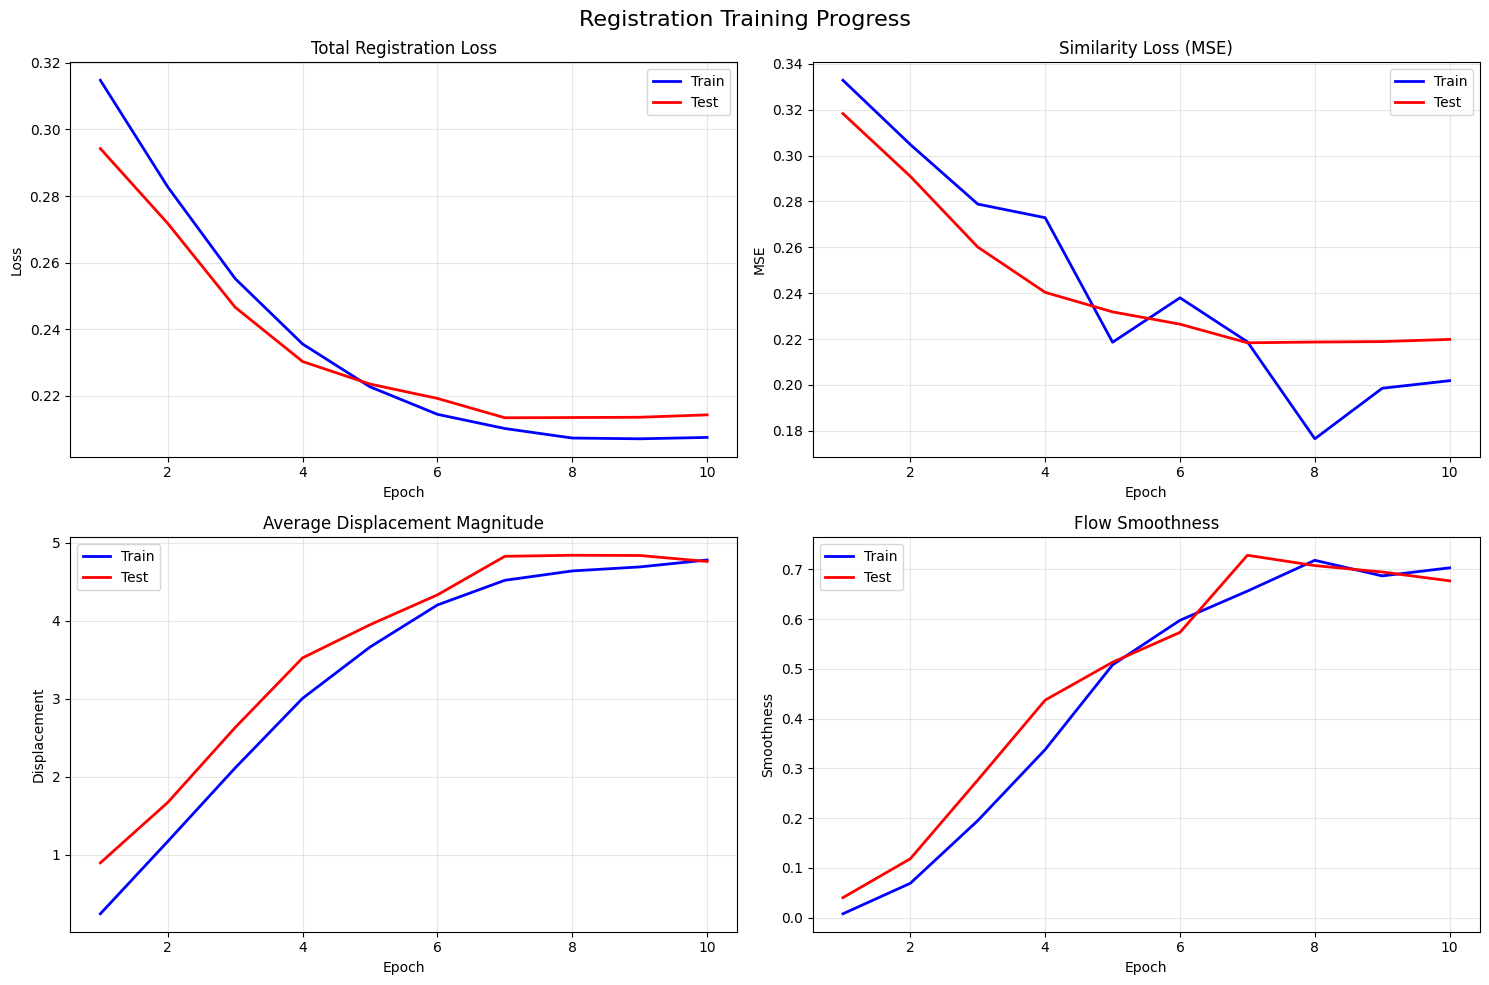


🖼️  2. REGISTRATION RESULTS


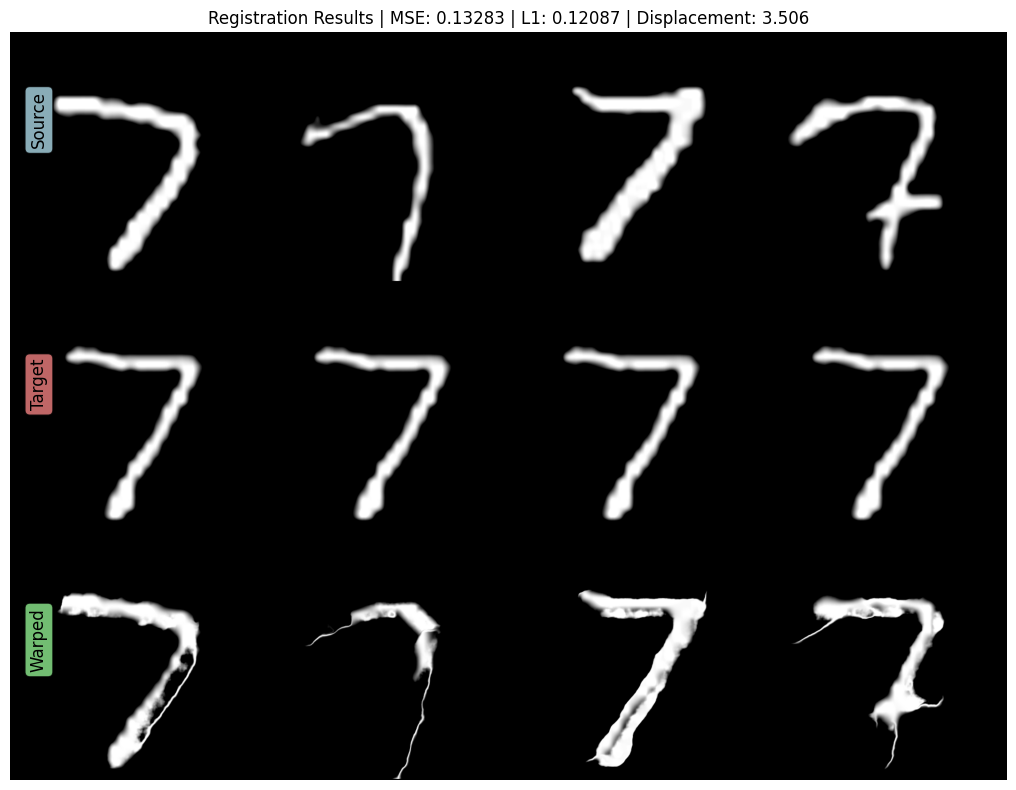


🌊 3. DISPLACEMENT FIELDS


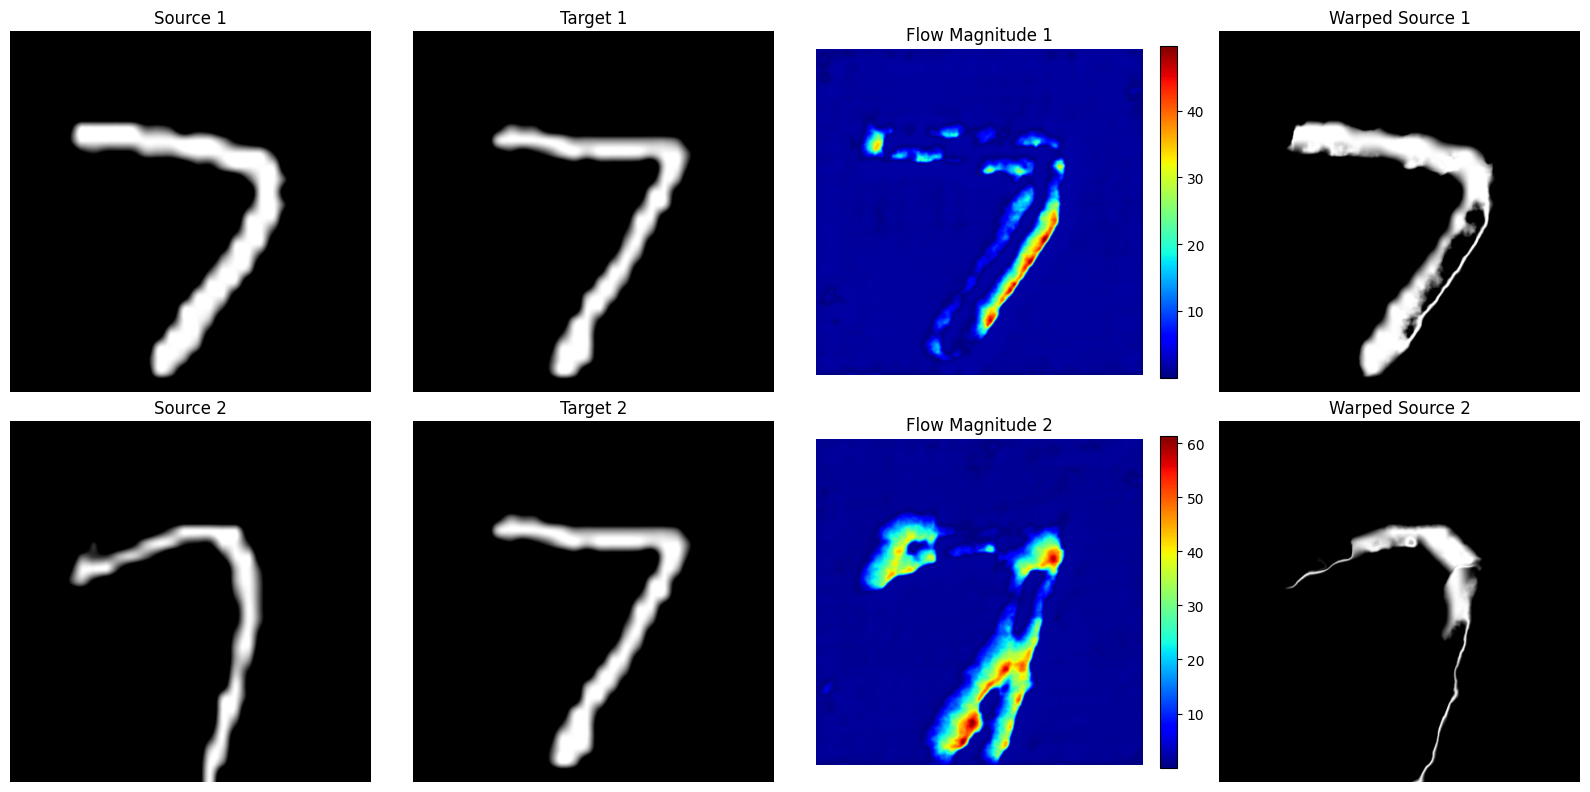


➡️  4. FLOW VECTORS


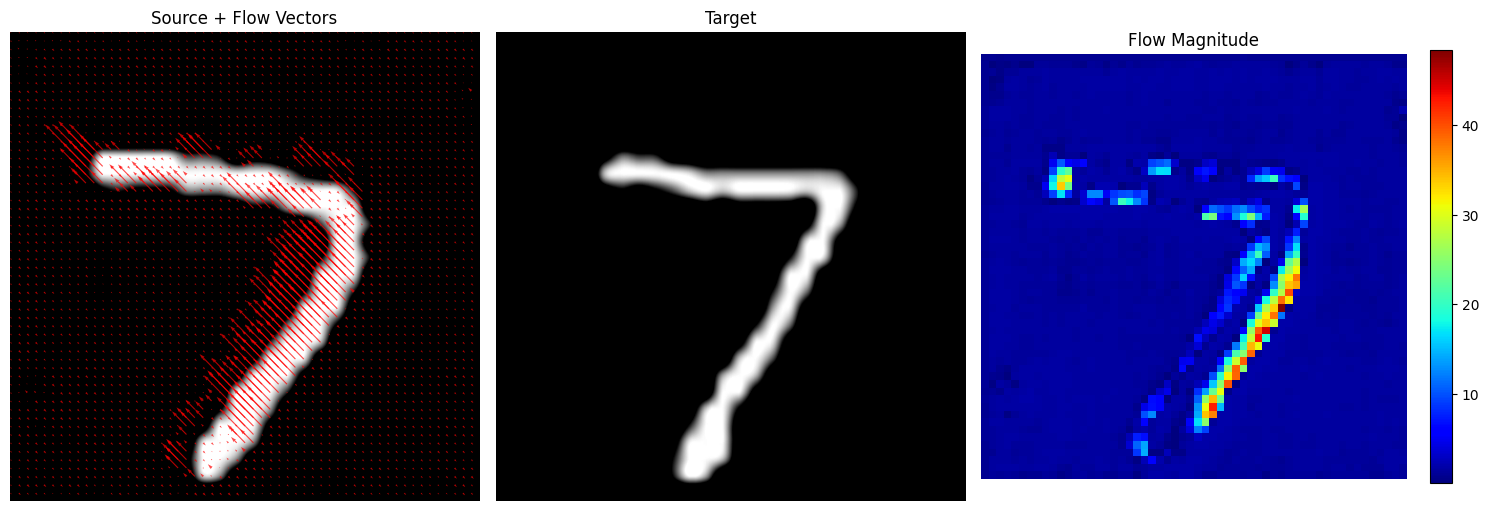


🔍 5. QUALITY ANALYSIS

🔍 REGISTRATION QUALITY ANALYSIS
📊 REGISTRATION METRICS (mean ± std):
  mse            : 0.17764 ± 0.04267
  l1             : 0.14994 ± 0.02797
  displacement_mag: 4.52475 ± 0.72483
  flow_smoothness: 0.66776 ± 0.10548
  ⚠️  FAIR registration quality (MSE < 0.2)
  ⚠️  ROUGH displacement fields

📏 DISPLACEMENT ANALYSIS:
  Average displacement: 4.525 pixels
  ✅ Small displacements (< 5 pixels)

✅ ANALYSIS COMPLETE!


In [ ]:
# === EXECUTE VISUALIZATION AFTER TRAINING ===
def setup_test_loader():
    """Recreate test loader for visualization"""
    processor = AutoProcessor.from_pretrained("google/medsiglip-448")

    # Load MNIST test dataset
    test_dataset = load_dataset("mnist", split="test")

    # Sample 5 images per class for testing
    test_class_samples = {}
    for item in test_dataset:
        label = item['label']
        if label not in test_class_samples:
            test_class_samples[label] = []
        if len(test_class_samples[label]) < 5:
            test_class_samples[label].append(item)

        if all(len(samples) == 5 for samples in test_class_samples.values()):
            break

    # Flatten samples for pairing
    test_samples = [item for samples in test_class_samples.values() for item in samples]

    # Create pairs
    test_pairs = create_mnist_pairs(test_samples, pairs_per_class=10)

    # Create data loader
    collate_fn = partial(collate_mnist_pairs, processor=processor)
    test_loader = DataLoader(test_pairs, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

    return test_loader

# Execute all visualizations
def run_all_visualizations(model, train_history, test_history):
    """Execute all visualization functions"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Setup test loader
    print("Setting up test loader...")
    test_loader = setup_test_loader()

    # Run complete analysis
    print("\n🎯 STARTING COMPLETE ANALYSIS")
    print("="*60)

    # 1. Training curves
    print("\n📈 1. TRAINING CURVES")
    plot_registration_curves(train_history, test_history)

    # 2. Registration results
    print("\n🖼️  2. REGISTRATION RESULTS")
    visualize_registration_results(model, test_loader, device, num_samples=4)

    # 3. Displacement fields
    print("\n🌊 3. DISPLACEMENT FIELDS")
    visualize_displacement_fields(model, test_loader, device, num_samples=2)

    # 4. Flow vectors
    print("\n➡️  4. FLOW VECTORS")
    visualize_flow_vectors(model, test_loader, device, num_samples=1)

    # 5. Quality analysis
    print("\n🔍 5. QUALITY ANALYSIS")
    analyze_registration_quality(model, test_loader, device)

    print("\n✅ ANALYSIS COMPLETE!")

# EXECUTE THIS AFTER TRAINING:
if __name__ == "__main__":
    # If you have the model and history from training:
    run_all_visualizations(model, train_history, test_history)